# Random Forest Theory — Why It Beats a Single Decision Tree

This notebook visually demonstrates the **classic ML interview question**:

> "Why use Random Forest instead of a single Decision Tree?"

**Answer (in short):** A single Decision Tree tends to **overfit** as it grows deeper — low bias,
but high variance (great on training data, unstable on test data). Random Forest keeps the low bias
but **reduces the variance**, by combining many trees trained on different random samples of rows
and features.

> **Real-life analogy:** A student who *memorizes* the exact textbook scores 100% on practice
> questions but struggles with reworded exam questions (single Decision Tree). A student who
> *understands* the concept from many varied examples performs consistently well on both
> (Random Forest).

We'll reproduce this effect on a synthetic dataset by sweeping tree depth and comparing a single
Decision Tree against a Random Forest.


## 1. Imports & Synthetic Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=2000, n_features=15, n_informative=8, n_redundant=2,
    n_classes=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


## 2. The Overfitting Curve — Single Decision Tree vs Random Forest

We'll train models at increasing `max_depth` values and track:
- Decision Tree: Train accuracy vs Test accuracy (watch the gap widen — that's overfitting)
- Random Forest: Test accuracy only (watch how much more stable it is)

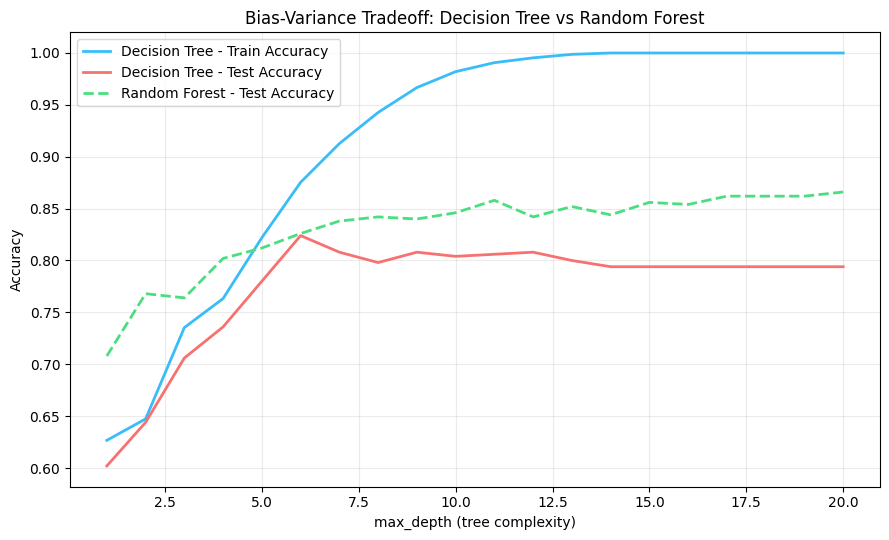

Notice: the gap between DT-Train and DT-Test widens as depth increases (overfitting),
while Random Forest's test accuracy stays comparatively higher and more stable.


In [2]:
depths = range(1, 21)
dt_train_scores, dt_test_scores, rf_test_scores = [], [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    dt_train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    dt_test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

    rf = RandomForestClassifier(max_depth=d, n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_test_scores.append(accuracy_score(y_test, rf.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(depths, dt_train_scores, label="Decision Tree - Train Accuracy", color="#38bdf8", linewidth=2)
ax.plot(depths, dt_test_scores, label="Decision Tree - Test Accuracy", color="#f87171", linewidth=2)
ax.plot(depths, rf_test_scores, label="Random Forest - Test Accuracy", color="#4ade80",
        linewidth=2, linestyle="--")
ax.set_xlabel("max_depth (tree complexity)")
ax.set_ylabel("Accuracy")
ax.set_title("Bias-Variance Tradeoff: Decision Tree vs Random Forest")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Notice: the gap between DT-Train and DT-Test widens as depth increases (overfitting),")
print("while Random Forest's test accuracy stays comparatively higher and more stable.")


## 3. Row Sampling + Feature Sampling — Seeing It in Action

Each tree inside a Random Forest is trained on a **different random subset of rows and features**.
Let's peek at two individual trees from a trained forest and confirm they used different data.

In [3]:
rf = RandomForestClassifier(n_estimators=10, max_features='sqrt', random_state=42, bootstrap=True)
rf.fit(X_train, y_train)

# Each tree stores which training rows it actually used (via bootstrap sample indices)
from sklearn.ensemble._forest import _generate_sample_indices

n_samples = X_train.shape[0]
tree0_indices = set(_generate_sample_indices(rf.estimators_[0].random_state, n_samples, n_samples))
tree1_indices = set(_generate_sample_indices(rf.estimators_[1].random_state, n_samples, n_samples))

overlap = len(tree0_indices & tree1_indices)
print(f"Tree 0 used {len(tree0_indices)} unique rows (out of {n_samples}, with replacement)")
print(f"Tree 1 used {len(tree1_indices)} unique rows (out of {n_samples}, with replacement)")
print(f"Rows used by BOTH trees: {overlap} -> confirms each tree sees a different sample of the data")


Tree 0 used 952 unique rows (out of 1500, with replacement)
Tree 1 used 951 unique rows (out of 1500, with replacement)
Rows used by BOTH trees: 615 -> confirms each tree sees a different sample of the data


## 4. Feature Importance — Which Features Matter Most?

Random Forest can tell you which features were most useful across all trees — very useful for
understanding your data (and for feature selection in later projects).

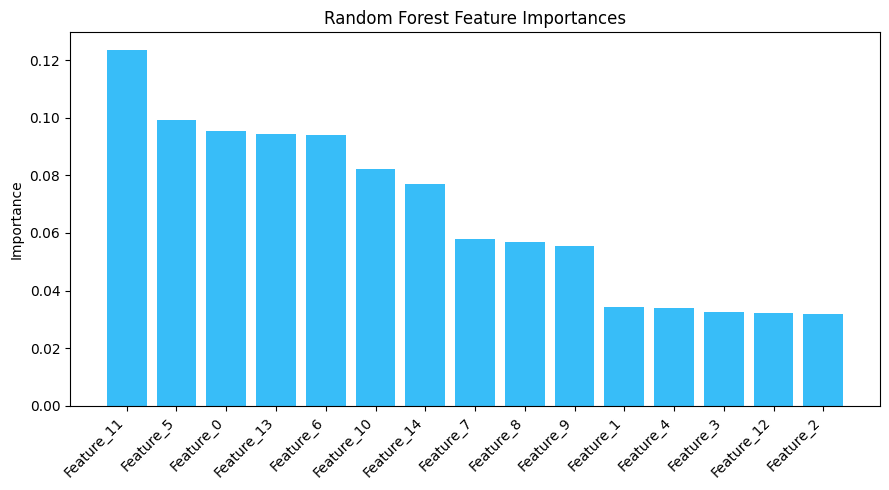

In [4]:
rf_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_full.fit(X_train, y_train)

importances = rf_full.feature_importances_
feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]

order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(importances)), importances[order], color="#38bdf8")
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in order], rotation=45, ha='right')
ax.set_ylabel("Importance")
ax.set_title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()




-  A single Decision Tree's **test accuracy degrades relative to train accuracy** as it grows deeper — classic overfitting (low bias, high variance).
- **Random Forest's test accuracy stays comparatively more stable** across depths — it keeps the low bias but reduces variance.
-  Each tree in the forest genuinely sees a **different random sample of rows** (confirmed above) — this diversity is *why* averaging their votes works so well.
-  **Feature importances** from a trained Random Forest are a great first step for understanding which inputs actually drive predictions.


